In [31]:
import tensorflow as tf
# 学習データ
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train",
    image_size=(96, 96),
    label_mode="binary",
    batch_size=50,
    shuffle=False
)
# テストデータ
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test",
    image_size=(96, 96),
    label_mode="binary",
    batch_size=50,
    shuffle=False
)


Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


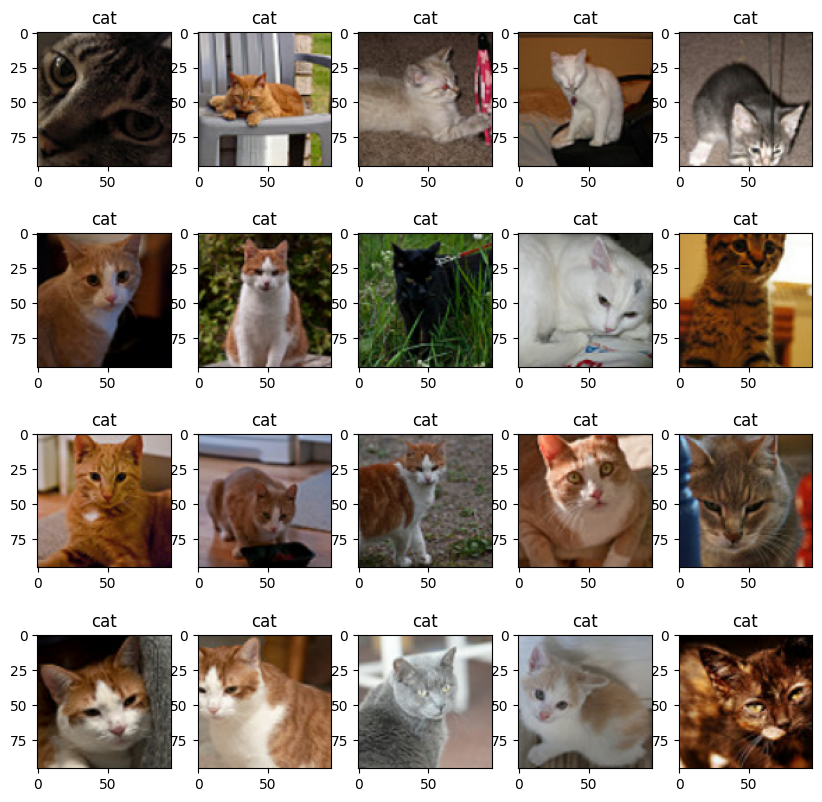

In [37]:
import matplotlib.pyplot as plt

# 訓練データの一部を表示して確認
class_names = train_dataset.class_names
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(20):
        ax = plt.subplot(4, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [26]:
# 左右反転
def flip_left_right(image, label):
    image = tf.image.flip_left_right(image)
    return image, label

# 反時計回りに180度回転
def rot180(image, label):
    image = tf.image.rot90(image, k=2)
    return image, label

# 左右反転
train_dataset_lr = train_dataset.map(flip_left_right)
# 反時計回りに180度回転
train_dataset_rot180 = train_dataset.map(rot180)

# 左右反転追加
train_dataset = train_dataset.concatenate(train_dataset_lr)
# 反時計回りに180度回転追加
train_dataset = train_dataset.concatenate(train_dataset_rot180)

In [27]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(96, 96, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理（正規化）をする層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(96, 96, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)
base_model.trainable = False

# 出力層
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

# モデル作成
model = tf.keras.Sequential([
    base_model,
    output_layer
])

# モデル完成
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [28]:
# 学習
model.fit(train_dataset, epochs=20)

# テスト
pred_data = model.predict(test_dataset)

# 評価
model.evaluate(test_dataset)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5944 - loss: 0.9041
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7744 - loss: 0.4826
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8722 - loss: 0.3212
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9044 - loss: 0.2509
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9233 - loss: 0.2149
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9389 - loss: 0.1880
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9489 - loss: 0.1687
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9544 - loss: 0.1533
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9589 - loss: 0.1406
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9633 - loss: 0.1299
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9656 - loss: 0.1207
Epoch 12/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy:

[0.05183413624763489, 0.9800000190734863]